<a href="https://colab.research.google.com/github/Kumarsakthi835/Python-Social-Media-Engagement-Analytics/blob/main/Social_Media_Engagement_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import pandas as pd

# Upload file
uploaded = files.upload()

# Load dataset
df = pd.read_csv('social_media_engagement_5000.csv')
print("Shape:", df.shape)
print(df.head())

Saving social_media_engagement_5000.csv to social_media_engagement_5000.csv
Shape: (5000, 19)
   user_id   age  gender country  post_id post_type post_category    likes  \
0    25795  43.0  Female  Brazil   496713     image       fitness   7011.0   
1    10860  33.0    Male  Brazil   157326      reel          food  11750.0   
2    86820  32.0  Female      UK   109864      text          food   4862.0   
3    64886  51.0   Other  France   848877      text       fitness   5350.0   
4    16265  34.0   Other      UK   449706     image       fitness  12682.0   

   comments  shares  watch_time_sec  impression_count   posted_at  \
0     354.0  1157.0            5726             44650  17-12-2022   
1    2606.0  1807.0            5947             80216  02-06-2023   
2     344.0   955.0            6946             44858  07-05-2023   
3    1083.0  1049.0             229             70455  12-02-2023   
4    2735.0  1300.0            4798              6019  23-05-2023   

   follower_count  is_

In [ ]:
#Data Import & Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('social_media_engagement_5000.csv')

# Check shape and columns
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

# Check data types
print("\nData Types:")
print(df.dtypes)

# Convert date column to datetime
df['posted_at'] = pd.to_datetime(df['posted_at'], dayfirst=True)
print("\nAfter datetime conversion:")
print(df['posted_at'].dtype)

# View first 5 rows
print("\nFirst 5 rows:")
print(df.head())

Shape: (5000, 19)

Columns: ['user_id', 'age', 'gender', 'country', 'post_id', 'post_type', 'post_category', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'posted_at', 'follower_count', 'is_verified', 'device_type', 'sentiment', 'hashtags', 'engagement_rate']

Data Types:
user_id               int64
age                 float64
gender               object
country              object
post_id               int64
post_type            object
post_category        object
likes               float64
comments            float64
shares              float64
watch_time_sec        int64
impression_count      int64
posted_at            object
follower_count        int64
is_verified            bool
device_type          object
sentiment            object
hashtags             object
engagement_rate     float64
dtype: object

After datetime conversion:
datetime64[ns]

First 5 rows:
   user_id   age  gender country  post_id post_type post_category    likes  \
0    25795  43.0  Fema

In [ ]:
#Data Cleaning
#Check missing values
print("Missing Values Before Cleaning:")
print(df.isnull().sum())

#Numerical missing values with median
df['age'] = df['age'].fillna(df['age'].median())
df['likes'] = df['likes'].fillna(df['likes'].median())
df['comments'] = df['comments'].fillna(df['comments'].median())
df['shares'] = df['shares'].fillna(df['shares'].median())

#Categorical missing values with mode
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])
df['sentiment'] = df['sentiment'].fillna(df['sentiment'].mode()[0])

#Missing values after cleaning
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

#Check and remove duplicates
print("\nDuplicates Before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicates After:", df.duplicated().sum())

#Standardize gender labels
df['gender'] = df['gender'].str.strip().str.capitalize()
print("\nUnique Gender Values:", df['gender'].unique())

#Standardize sentiment labels
df['sentiment'] = df['sentiment'].str.strip().str.lower()
print("Unique Sentiment Values:", df['sentiment'].unique())

#Fix unrealistic values
df = df[df['likes'] >= 0]
df = df[df['comments'] >= 0]
df = df[df['shares'] >= 0]

#Extract hashtag count
df['hashtag_count'] = df['hashtags'].apply(
    lambda x: len(str(x).split()) if pd.notnull(x) else 0)
print("\nHashtag Count Sample:")
print(df[['hashtags', 'hashtag_count']].head())

Missing Values Before Cleaning:
user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64

Missing Values After Cleaning:
user_id             0
age                 0
gender              0
country             0
post_id             0
post_type           0
post_category       0
likes               0
comments            0
shares              0
watch_time_sec      0
impression_count    0
posted_at           0
follower_count      0
is_verified         0
device_type         0
sentiment           0
hashtags            0
engagement_rate     0
dtype: int64

Duplicates Before: 0
Duplicates Aft

In [ ]:
# Data Exploration using Pandas
# Head and Tail
print("Head:")
print(df.head())
print("\nTail:")
print(df.tail())

#Shape and Columns
print("\nShape:", df.shape)
print("Columns:", df.columns.tolist())

#Info and dtypes
print("\nInfo:")
df.info()
print("\nData Types:")
print(df.dtypes)

#Summary statistics
print("\nDescribe:")
print(df.describe())

#Categorical distributions
print("\nPost Type Distribution:")
print(df['post_type'].value_counts())
print("\nGender Distribution:")
print(df['gender'].value_counts())
print("\nSentiment Distribution:")
print(df['sentiment'].value_counts())
print("\nUnique Countries:", df['country'].nunique())
print("Unique Post Categories:", df['post_category'].unique())

#Correlation matrix
print("\nCorrelation Matrix:")
corr_cols = ['likes', 'comments', 'shares',
             'watch_time_sec', 'impression_count',
             'follower_count', 'engagement_rate']
print(df[corr_cols].corr())

#Groupby summaries
print("\nAvg Likes by Post Type:")
print(df.groupby('post_type')['likes'].mean())

print("\nAvg Impressions by Country:")
print(df.groupby('country')['impression_count'].mean())

Head:
   user_id   age  gender country  post_id post_type post_category    likes  \
0    25795  43.0  Female  Brazil   496713     image       fitness   7011.0   
1    10860  33.0    Male  Brazil   157326      reel          food  11750.0   
2    86820  32.0  Female      UK   109864      text          food   4862.0   
3    64886  51.0   Other  France   848877      text       fitness   5350.0   
4    16265  34.0   Other      UK   449706     image       fitness  12682.0   

   comments  shares  watch_time_sec  impression_count  posted_at  \
0     354.0  1157.0            5726             44650 2022-12-17   
1    2606.0  1807.0            5947             80216 2023-06-02   
2     344.0   955.0            6946             44858 2023-05-07   
3    1083.0  1049.0             229             70455 2023-02-12   
4    2735.0  1300.0            4798              6019 2023-05-23   

   follower_count  is_verified device_type sentiment               hashtags  \
0           81734        False      m

In [ ]:
#Data Wrangling
#Engagement_score
df['engagement_score'] = (
    df['likes'] + df['comments'] * 2 + df['shares'] * 3
) / df['impression_count']

#log-transformed metrics
df['log_likes'] = np.log1p(df['likes'])
df['log_followers'] = np.log1p(df['follower_count'])

# Extract date features
df['hour'] = df['posted_at'].dt.hour
df['day_of_week'] = df['posted_at'].dt.day_name()
df['month'] = df['posted_at'].dt.month

print("New Columns Added:")
print(df[['engagement_score', 'log_likes',
          'log_followers', 'hour',
          'day_of_week', 'month']].head())

# Groupby summaries
print("\nAvg Engagement Score by Post Type:")
print(df.groupby('post_type')['engagement_score'].mean())

print("\nAvg Likes by Country:")
print(df.groupby('country')['likes'].mean())

print("\nAvg Engagement by Sentiment:")
print(df.groupby('sentiment')['engagement_rate'].mean())

# Concat example
df_verified = df[df['is_verified'] == True].copy()
df_non_verified = df[df['is_verified'] == False].copy()
df_combined = pd.concat([df_verified, df_non_verified])
print("\nCombined Shape:", df_combined.shape)

New Columns Added:
   engagement_score  log_likes  log_followers  hour day_of_week  month
0          0.250616   8.855378      11.311238     0    Saturday     12
1          0.279034   9.371694       8.693497     0      Friday      6
2          0.187592   8.489411      13.125925     0      Sunday      5
3          0.151345   8.585039      13.081985     0      Sunday      2
4          3.663732   9.448018      12.858234     0     Tuesday      5

Avg Engagement Score by Post Type:
post_type
image    1.144731
reel     1.021004
text     1.363262
video    1.397012
Name: engagement_score, dtype: float64

Avg Likes by Country:
country
Australia    10294.124746
Brazil        9886.689484
Canada       10063.066277
France       10372.876008
Germany      10130.458163
India         9962.468224
Japan        10088.862288
UAE          10227.487078
UK            9935.650101
USA          10122.361277
Name: likes, dtype: float64

Avg Engagement by Sentiment:
sentiment
negative    1.038486
neutral     0.9911

In [ ]:
#Statistical Analysis
stats_cols = ['likes', 'comments', 'shares',
              'watch_time_sec', 'engagement_rate',
              'follower_count']

print("=" * 50)
print("DESCRIPTIVE STATISTICS")
print("=" * 50)

for col in stats_cols:
    print(f"\n--- {col.upper()} ---")
    print(f"Mean:     {df[col].mean():.2f}")
    print(f"Median:   {df[col].median():.2f}")
    print(f"Mode:     {df[col].mode()[0]:.2f}")
    print(f"Std Dev:  {df[col].std():.2f}")
    print(f"Variance: {df[col].var():.2f}")
    print(f"25th Pct: {df[col].quantile(0.25):.2f}")
    print(f"75th Pct: {df[col].quantile(0.75):.2f}")
    print(f"Skewness: {df[col].skew():.2f}")
    print(f"Kurtosis: {df[col].kurt():.2f}")

DESCRIPTIVE STATISTICS

--- LIKES ---
Mean:     10107.00
Median:   10105.50
Mode:     10105.50
Std Dev:  5702.29
Variance: 32516145.65
25th Pct: 5235.00
75th Pct: 14959.00
Skewness: -0.01
Kurtosis: -1.15

--- COMMENTS ---
Mean:     1502.04
Median:   1497.00
Mode:     1497.00
Std Dev:  856.39
Variance: 733409.50
25th Pct: 792.00
75th Pct: 2235.25
Skewness: 0.00
Kurtosis: -1.14

--- SHARES ---
Mean:     1002.91
Median:   1012.00
Mode:     1012.00
Std Dev:  570.86
Variance: 325875.66
25th Pct: 511.00
75th Pct: 1483.00
Skewness: -0.01
Kurtosis: -1.15

--- WATCH_TIME_SEC ---
Mean:     4014.50
Median:   4034.50
Mode:     916.00
Std Dev:  2308.10
Variance: 5327309.26
25th Pct: 2017.75
75th Pct: 6020.25
Skewness: -0.02
Kurtosis: -1.20

--- ENGAGEMENT_RATE ---
Mean:     0.96
Median:   0.25
Mode:     0.01
Std Dev:  5.32
Variance: 28.28
25th Pct: 0.15
75th Pct: 0.50
Skewness: 18.78
Kurtosis: 482.99

--- FOLLOWER_COUNT ---
Mean:     393698.22
Median:   388982.00
Mode:     497502.00
Std Dev:  23092

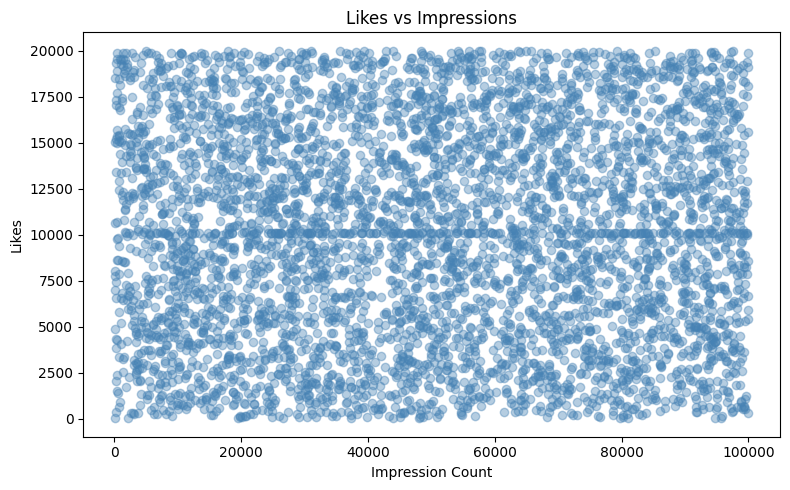

In [ ]:
#Matplotlib Visualizations
#1:Scatter - Likes vs Impressions
plt.figure(figsize=(8, 5))
plt.scatter(df['impression_count'], df['likes'],
            alpha=0.4, color='steelblue')
plt.title('Likes vs Impressions')
plt.xlabel('Impression Count')
plt.ylabel('Likes')
plt.tight_layout()
plt.show()

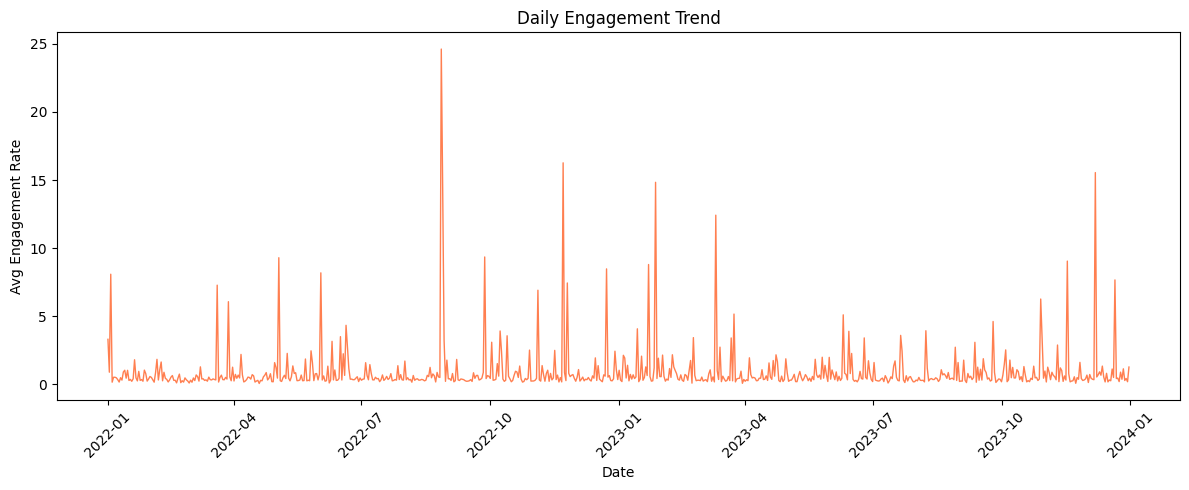

In [ ]:
#2: Line - Daily Engagement Trend
daily = df.groupby(df['posted_at'].dt.date)['engagement_rate'].mean()
plt.figure(figsize=(12, 5))
plt.plot(daily.index, daily.values,
         color='coral', linewidth=1)
plt.title('Daily Engagement Trend')
plt.xlabel('Date')
plt.ylabel('Avg Engagement Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

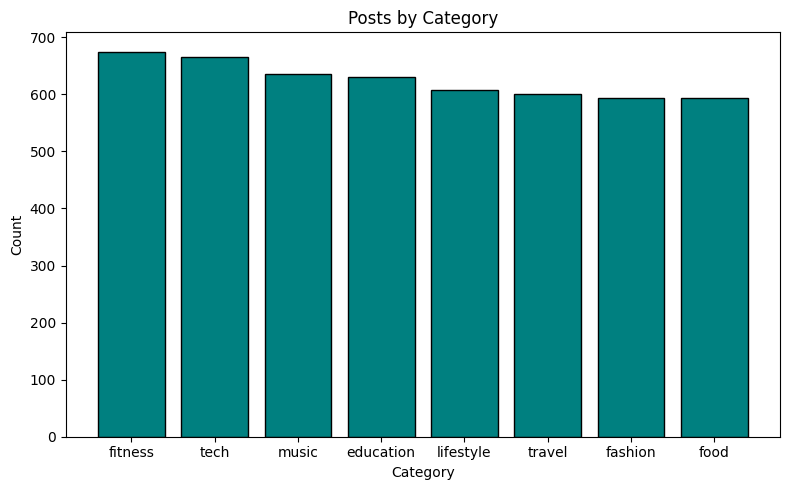

In [ ]:
#3: Bar - Posts by Category
category_counts = df['post_category'].value_counts()
plt.figure(figsize=(8, 5))
plt.bar(category_counts.index, category_counts.values,
        color='teal', edgecolor='black')
plt.title('Posts by Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

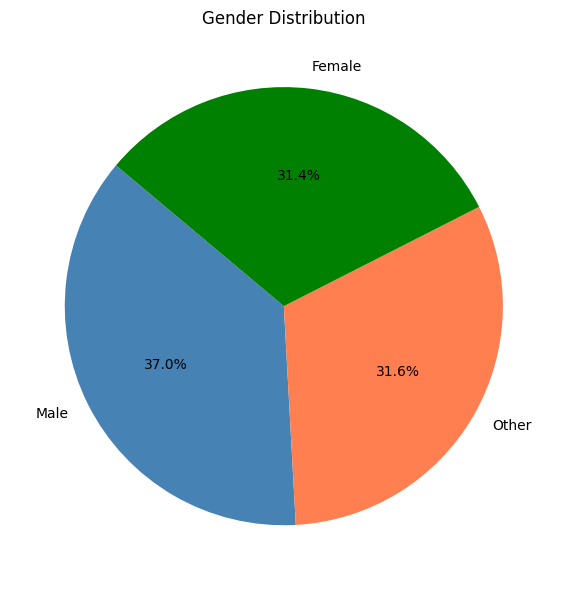

In [ ]:
#4: Pie - Gender Distribution
gender_counts = df['gender'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(gender_counts, labels=gender_counts.index,
        autopct='%1.1f%%', startangle=140,
        colors=['steelblue', 'coral', 'green'])
plt.title('Gender Distribution')
plt.tight_layout()
plt.show()

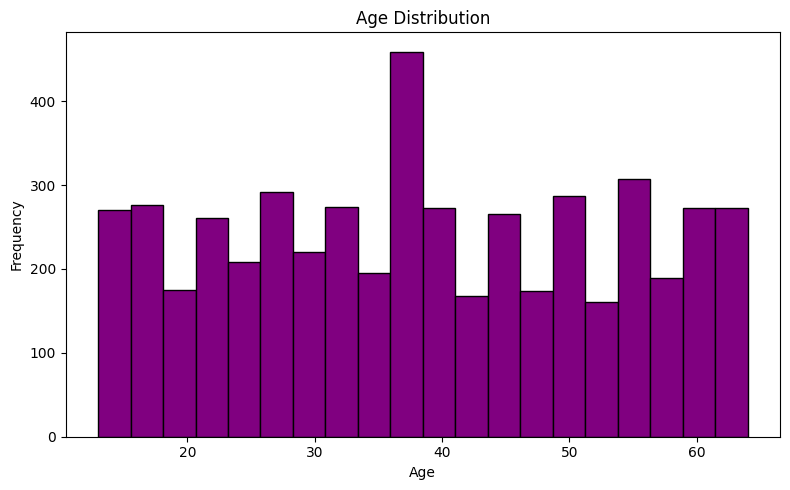

In [ ]:
#5: Histogram - Age Distribution
plt.figure(figsize=(8, 5))
plt.hist(df['age'], bins=20, color='purple',
         edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

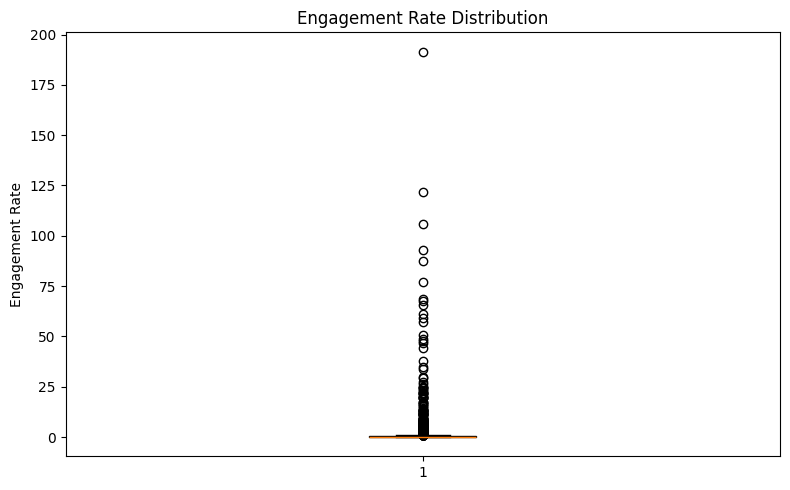

In [ ]:
#6: Box - Engagement Rate
plt.figure(figsize=(8, 5))
plt.boxplot(df['engagement_rate'].dropna(),
            patch_artist=True,
            boxprops=dict(facecolor='lightblue'))
plt.title('Engagement Rate Distribution')
plt.ylabel('Engagement Rate')
plt.tight_layout()
plt.show()

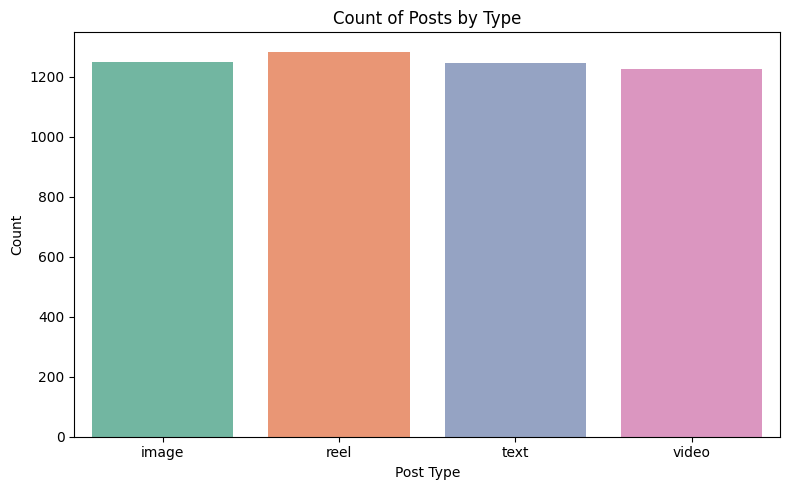

In [ ]:
#7:Count Plot - Post Type
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='post_type', palette='Set2')
plt.title('Count of Posts by Type')
plt.xlabel('Post Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

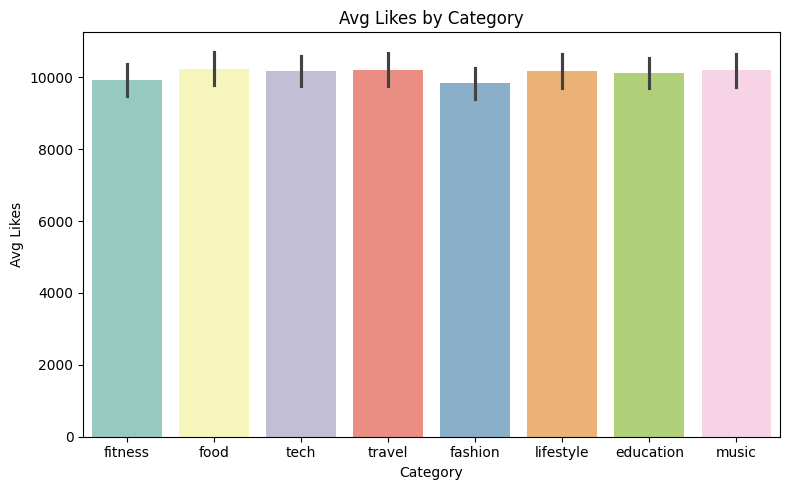

In [ ]:
#8:Bar Plot - Avg Likes by Category
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='post_category',
            y='likes', palette='Set3',
            estimator=np.mean)
plt.title('Avg Likes by Category')
plt.xlabel('Category')
plt.ylabel('Avg Likes')
plt.tight_layout()
plt.show()

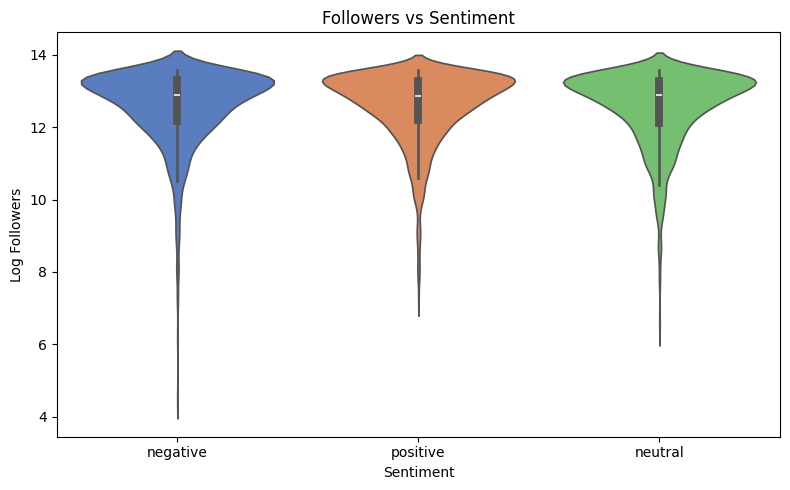

In [ ]:
#9: Violin - Followers vs Sentiment
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='sentiment',
               y='log_followers', palette='muted')
plt.title('Followers vs Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Log Followers')
plt.tight_layout()
plt.show()

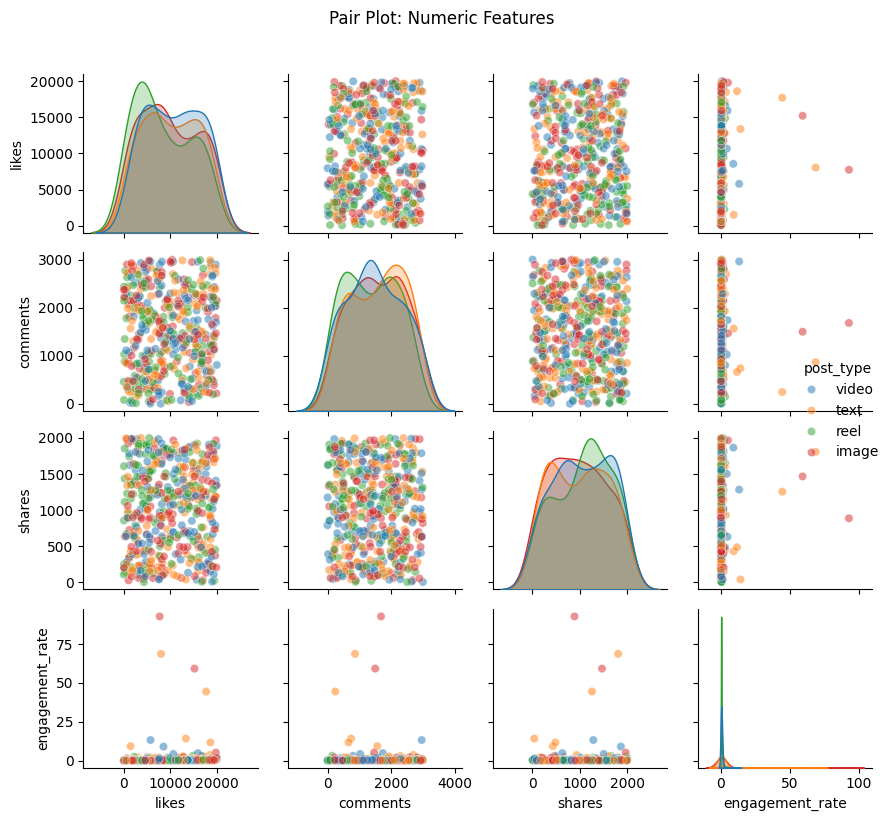

In [ ]:
#10: Pair Plot
pair_df = df[['likes', 'comments', 'shares',
              'engagement_rate', 'post_type']].sample(500)
sns.pairplot(pair_df, hue='post_type',
             plot_kws={'alpha': 0.5}, height=2)
plt.suptitle('Pair Plot: Numeric Features', y=1.02)
plt.tight_layout()
plt.show()

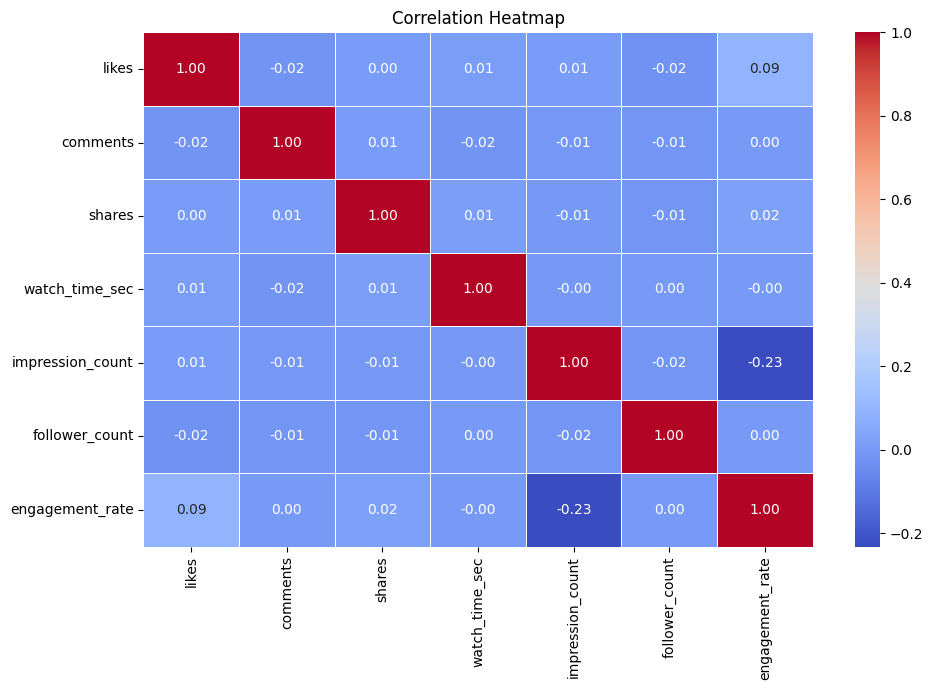

In [ ]:
#11: Heatmap- Correlation Matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
corr = df[['likes', 'comments', 'shares',
           'watch_time_sec', 'impression_count',
           'follower_count', 'engagement_rate']].corr()
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1385/3387724988.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=df.sample(300),
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 8.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


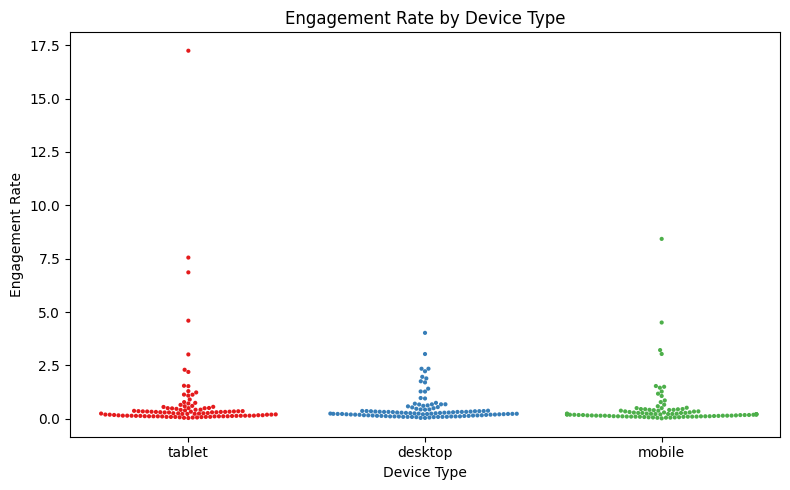

In [ ]:
#12: Swarm Plot - Engagement vs Device
plt.figure(figsize=(8, 5))
sns.swarmplot(data=df.sample(300),
              x='device_type',
              y='engagement_rate',
              palette='Set1', size=3)
plt.title('Engagement Rate by Device Type')
plt.xlabel('Device Type')
plt.ylabel('Engagement Rate')
plt.tight_layout()
plt.show()

In [ ]:
#13.Plotly Interactive Scatter
import plotly.express as px

fig = px.scatter(df, x='impression_count', y='likes',
                 color='post_type',
                 title='Interactive: Likes vs Impressions',
                 labels={'impression_count': 'Impressions',
                         'likes': 'Likes'},
                 opacity=0.6)
fig.show()

In [ ]:
#7: Final Insights
df['posted_at'] = pd.to_datetime(df['posted_at'], dayfirst=True)
df['hour'] = df['posted_at'].dt.hour
df['day_of_week'] = df['posted_at'].dt.day_name()
df['month'] = df['posted_at'].dt.month
df['age_group'] = pd.cut(df['age'],
    bins=[0, 25, 35, 45, 60, 100],
    labels=['<25', '25-35', '35-45', '45-60', '60+'])

print("FINAL INSIGHTS")
print("=" * 55)

print("CONTENT PERFORMANCE")
print("Top Post Type by Engagement:")
print(df.groupby('post_type')['engagement_rate'].mean().sort_values(ascending=False))

print("Best Post Category by Likes:")
print(df.groupby('post_category')['likes'].mean().sort_values(ascending=False))

print("Top Countries by Avg Engagement Rate:")
print(df.groupby('country')['engagement_rate'].mean().sort_values(ascending=False))

print("USER TRENDS")
print("Avg Engagement by Age Group:")
print(df.groupby('age_group', observed=False)['engagement_rate'].mean())

print("Verified vs Non-Verified Engagement:")
print(df.groupby('is_verified')['engagement_rate'].mean())

print("BEHAVIORAL INSIGHTS")
print("Best Hour for Impressions:")
print(df.groupby('hour')['impression_count'].mean().sort_values(ascending=False).head(5))

print("Device Type Impact on Watch Time:")
print(df.groupby('device_type')['watch_time_sec'].mean().sort_values(ascending=False))

print("SENTIMENT ANALYSIS")
print("Avg Engagement by Sentiment:")
print(df.groupby('sentiment')['engagement_rate'].mean().sort_values(ascending=False))

print("Avg Likes by Sentiment:")
print(df.groupby('sentiment')['likes'].mean().sort_values(ascending=False))

FINAL INSIGHTS
CONTENT PERFORMANCE
Top Post Type by Engagement:
post_type
video    1.122365
text     1.064549
image    0.895646
reel     0.783047
Name: engagement_rate, dtype: float64
Best Post Category by Likes:
post_category
food         10230.585237
music        10208.340872
travel       10198.951973
lifestyle    10184.053448
tech         10172.992320
education    10127.138889
fitness       9910.263636
fashion       9835.164931
Name: likes, dtype: float64
Top Countries by Avg Engagement Rate:
country
Brazil       1.540704
Australia    1.324339
France       1.146402
UAE          1.112352
Canada       0.916659
UK           0.850966
Japan        0.769623
Germany      0.759000
India        0.655005
USA          0.576580
Name: engagement_rate, dtype: float64
USER TRENDS
Avg Engagement by Age Group:
age_group
<25      0.971214
25-35    0.865316
35-45    0.858642
45-60    1.152669
60+      0.801381
Name: engagement_rate, dtype: float64
Verified vs Non-Verified Engagement:
is_verified
False